# Lecture 2b: Model Evaluation
Notebook Lecture 2b

*Data Science in Auditing - Nyenrode*

***

Cheatsheet: please **read the section 'Evaluation Metrics in Linear Regression' in the cheatsheet**, before you get started.

# 2. Linear Regression: Model Evaluation Exercises



### 2.1. Importing data

Q2.1.1. Download the _Staten_Island_housing_market_case.xlsx_ file from Canvas and save it to a folder of your choice. **IMPORTANT! Make sure to save the file under the name "Staten_Island_housing_market_case".**
Q2.1.2 Once the dataset is saved, upload it to your Google Colab files, using the right most _Upload_ button, as shown in the screenshot below:

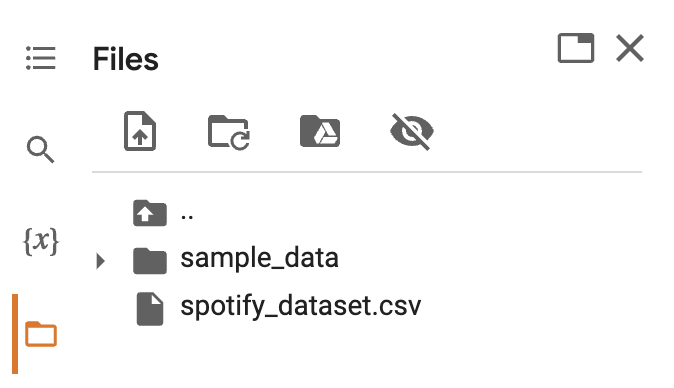



Q2.1.2. Import the pandas and statmodels Python libraries. Import the _Staten_Island_housing_market_case.xlsx_ file, delete the rows with missing values and show the top lines of datafile.

In [ ]:
#A.1.2)
import pandas as pd
import os
staten_island_df = pd.read_excel(os.path.join(os.getcwd(), "Staten_Island_housing_market_case.xlsx"))

staten_island_df = staten_island_df.dropna()
staten_island_df.head()

Q2.1.3. When evaluating a statistical or machine learning model, it is important to understand how well the model is performing on data it has not seen before. How could we simulate having unseen data?

A2.1.3)

Q2.1.4. When splitting data into a train and test set, the train set should be much bigger than the test set. (A) Discuss why this is the case. (B) Why is it important to do a random split when splitting the original dataset into a train and test set?

A2.1.4)

Q2.1.5. Before splitting the data into a train and test set, you must determine the y and X features. In this case we have already given the names of the features that we would like to use to predict the price, and created a list containing these names (```X_features_list```)? Please create the feature variable X and the dependent variable y. 

In [ ]:
#A2.1.5)
X_features_list = ['land_sqft' , 'tot_sqft', 'yr_built' , 'sale_date' , 'long' , 'lat' , 'atm' , 'bank' , 'bar' ,
                   'book_store' , 'bus_station' , 'cafe' , 'church' , 'city_hall' , 'doctor', 'fire_station' ,
                   'gas_station' , 'gym' , 'hospital' , 'library' , 'lodging', 'mosque',
                   'movie_theater' , 'museum' , 'night_club', 'park' , 'parking' , 'police',
                   'restaurant', 'school', 'shopping_mall', 'store', 'supermarket', 'train_station']

 Now that we've created the y and X variables, let's split them up in dependent (y) and independent (X) train and test features. We do this by using the sklearn function train_test_split:

In [ ]:
from sklearn.model_selection import train_test_split

Q2.1.6) Use the train_test_split() function from the Sklearn library to split the data into a train and test set with a 80/20 division. Name the train and the test sets: X_train, X_test, y_train, y_test. To make sure that everybody has the same results, add the parameter random_state=1 to your train_test_split command. For more information about this see here: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html.

In [ ]:
#A2.1.6) 

 Now that we created a train and test set, we can train a multivariate regression model on the train set. In order to do this we will import the statsmodels library. 

In [ ]:
import statsmodels.api as sm

Q2.1.7) Look at the regression table and answer the following question: there is a new restaurant being built within 500m meters of a Staten Island home. According to this model, will this leads to an increase or decrease in property value?

In [ ]:
# Adding the constant term for the intercept
X_train = sm.add_constant(X_train)

# Fitting the model
multivar_linreg = sm.OLS(y_train, X_train).fit()

# Printing the summary of the model
print(multivar_linreg.summary())

A2.1.7)

Q2.1.8. Now that regression model has been trained on the train set, let's evaluate it's performance. To evaluate, we first need to know the predictions of the trained regression model. Create a pandas dataframe called ```train_evaluation_df```, add the y_train values to a newly created column in that dataframe and name that column ```price```. Finally, use the predict function on the previously created model ```multivar_linreg``` and X_train to predict prices based on X_train. Add these values to a new column called ```predicted_price``` in the train_evaluation dataframe.

In [ ]:
# A2.1.8)

Q2.1.9. When evaluating a regression model, you want to know how much the model's predicted price is off from the real price. This difference is called the 'error'. Let's create a new column, called 'error' and sort the values to answer the following questions: (A) What is the biggest prediction error caused by the model? (B) To what extent does that tell you how well the regression model is performing?

In [ ]:
# in order to have Python show large numbers not in scientific notation, we run the following command (you don't need to know this for your exam):
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
train_evaluation_df['error'] = train_evaluation_df['price'] - train_evaluation_df['predicted_price']
train_evaluation_df['error'].sort_values()

A2.1.9)

Let's create a visualisation of a subset of the sorted errors of the model by running the code below. We do this by making use of the library matplotlib.

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
# Sorting and plotting the errors
train_evaluation_df_subset = train_evaluation_df.iloc[1:100,:]
train_evaluation_df_subset['error'].sort_values().plot(kind='barh')

# Removing the y-axis labels (indexes)
plt.yticks([])

plt.title('Sorted Errors in Predictions (First 100 Rows)')

plt.show()


Q2.1.10. To What extent does this give a better overview of the performance of the model?

A2.1.10)

Q2.1.11. Visualizing the distribution of errors gives some insight into the performance of the model. But ideally, we want to calculate a single number that tracks performance. This will make it easier to compare different configurations of the same model and to compare performance on train and test set. This single number to evaluate performance is called an 'evaluation metric'. There are multiple evaluation metrics for regression. We will start with Mean Absolute Error. This is an intuitive metric that tracks the average of all absolute errors. Taking the absolute just means taking the positive version of any number. For example, the absolute of -5 is 5, while the absolute of 5 is also 5. Taking the absolute is done to make sure that all values that you're comparing are positive. First calculate the absolute error and insert it into a new column in train_evaluation_df called 'absolute_error'.

For this, we make use of the numpy function ```abs``` that calculates absolute values. See here for more information: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.abs.html

In [ ]:
#A.2.1.11)

Q2.1.12. Now that we've calculated the absolute errors, we can take the mean to calculate the Mean Absolute Error (MAE). (A) How high is the mean? (B) How would you interpret this number? Do you think it's high or low?

In [ ]:
#A.2.1.12)

Q2.1.13. While MAE is easy to interpret, it's downside is that it treats high and low errors in the same way. That's why the Mean Squared Error (MSE) is next. The MSE does punish bigger errors, by squaring them. Calculate the squared errors and insert it into the 'mean_squared_error' column. (A) What is the MSE? (B) To what extent are you able to interpret the MSE? (C) Can you explain why MSE "punishes" high errors harder than MAE?

In [ ]:
#A.2.1.13)

Q2.1.14. Mean Squared Error (MSE) is great at giving bigger errors more weight than MAE, but it can be a bit tricky to understand. That's why we turn to Root Mean Squared Error (RMSE) next. RMSE has the best of both worlds: it's easy to get what it's telling you and it still focuses on the bigger errors. It's pretty much just the MSE with an extra step - you take the square root of the MSE, which puts it back in the same units as your original data. Calculate the RMSE. (A) What is the RMSE number?

In [ ]:
#A.2.1.14)

Q2.1.15. After exploring Mean Absolute Error (MAE), Mean Squared Error (MSE) and Root Mean Squared Error (RMSE), we turn our attention to another important metric: Mean Absolute Percentage Error (MAPE). Unique in its approach, MAPE measures the error as a percentage of the actual values, making it useful for problems where the relative size of the error is more important than the absolute size. First calculate the percentage error and insert it into the 'percentage_error' column. Secondly, calculate the absolute percentage error and insert it in the 'absolute_percentage_error' column. Finally, calculate the MAPE by averaging the absolute_percentage_error. (A) What is the MAPE and how should this number be interpreted?

In [ ]:
# A2.1.15)

A2.1.15)

## 3. KNN: Model Evaluation Exercises

**Please read the Cheatsheet on KNN** before starting the exercises.

Now that we understand the how to evaluate regression, let's continue with KNN model evaluation. Let's first train a model like we did in previous seminar, but now with all numerical features instead of just total square feet and price.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# Exclude three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

# Assuming staten_island_df is your DataFrame
y = staten_island_df['bldg_ctgy']  # Target variable

X_features_list = ['land_sqft', 'tot_sqft', 'yr_built', 'sale_date', 'long', 'lat', 'atm', 'bank', 'bar',
                   'book_store', 'bus_station', 'cafe', 'church', 'city_hall', 'doctor', 'fire_station',
                   'gas_station', 'gym', 'hospital', 'library', 'lodging', 'mosque',
                   'movie_theater', 'museum', 'night_club', 'park', 'parking', 'police',
                   'restaurant', 'school', 'shopping_mall', 'store', 'supermarket', 'train_station']

X = staten_island_df[X_features_list]  # Features (all columns except the target)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)

# Normalizing the feature data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the KNN model
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train)

# Predicting and evaluating the model on the train data
y_pred_train = knn.predict(X_train_scaled)
conf_matrix = confusion_matrix(y_train, y_pred_train)

unique_classes = sorted(set(y_test))
conf_matrix_df = pd.DataFrame(conf_matrix, index=unique_classes, columns=unique_classes)

# Renaming the index and columns for clarity
conf_matrix_df.index.name = 'Actual'
conf_matrix_df.columns.name = 'Predicted'

print(conf_matrix_df)

Q3.1) Looking at the confusion matrix above, answer the following questions:
- (A) What are the True Positives?
- (B) What are the True Negatives?
- (C) What are the False Positives?
- (D) What are the False Negatives?

- Hint: take '01 ONE FAMILY HOMES' as being the 'true' class.

A3.1)

Q3.2) Now that we have the TP, FN, FP and TN, we can start calculating the first evaluation metric: accuracy. Accuracy is the proportion of total correct predictions (both positive and negative) relative to all predictions. Accuracy = (True Positives + True Negatives) / Total Observations. Calculate the accuracy for this KNN model on the train set. (A) Reflect on this number, is it high or low? (B) What are the pro's and cons of using accuracy for evaluation?

In [ ]:
#A3.2)

Q3.3) Precision is often preferred over accuracy in scenarios where the cost of false positives is high. It helps to understand the model's ability to avoid labeling negative samples as positive. Formula: Precision = True Positives / (True Positives + False Positives). Calculate the precision for this KNN model on the train set. (A) Reflect on this number. To what extent does it change your opinion of the model when comparing it to the accuracy?

In [ ]:
# A3.3)

Q3.4) Recall is emphasized over accuracy or precision in situations where missing a positive instance (false negatives) is more critical than incorrectly labeling negative instances as positive (false positives). It measures the model's ability to capture all relevant instances, which is vital in contexts where failing to detect a positive case has serious consequences. Formula: Recall = True Positives / (True Positives + False Negatives). Calculate the recall for this KNN model on the train set. (A) Reflect on this number. Which evaluation metric do you find more important for this problem? Accuracy, precision or recall? Explain why.

In [ ]:
#A3.4)